<a href="https://colab.research.google.com/github/Nupur-DS/Business-Insights-360-Dashboard/blob/main/Project1_EDA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Marketing Attribution Dataset - EDA

This notebook covers data loading, preprocessing, and exploratory data analysis (EDA) across three datasets: **Ad Spend**, **Web Analytics**, and **CRM Conversions**.

## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('Set2')

## 2. Load Dataset


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
file_path =  "/content/drive/MyDrive/Infotact proj 1/Project1_Marketing_Attribution_Dataset-1.xlsx"

ad_spend = pd.read_excel(file_path, sheet_name="Ad_Spend", header=2)
web = pd.read_excel(file_path, sheet_name="Web_Analytics", header=2)
crm = pd.read_excel(file_path, sheet_name="CRM_Conversions", header=2)

In [9]:
def dataset_summary(df, name):
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())
    display(df.describe(include='all'))
    print()

In [10]:
dataset_summary(ad_spend, "Ad Spend")
dataset_summary(web, "Web Analytics")
dataset_summary(crm, "CRM Conversions")

--- Ad Spend ---
Shape: (72, 11)

Missing Values:
campaign_id      0
campaign_name    0
channel          0
month            0
impressions      0
clicks           0
spend_usd        0
avg_cpc_usd      0
utm_source       0
utm_medium       0
utm_campaign     0
dtype: int64

Duplicates: 0


,campaign_id,campaign_name,channel,month,impressions,clicks,spend_usd,avg_cpc_usd,utm_source,utm_medium,utm_campaign
count,72,72,72,72,72.000000,72.000000,72.000000,72.000000,72,72,72
unique,72,12,5,6,NaN,NaN,NaN,NaN,5,2,12
top,C001,GS_Brand_Q1,Google Search,2024-01,NaN,NaN,NaN,NaN,google,cpc,gs_brand_q1
freq,1,6,18,12,NaN,NaN,NaN,NaN,18,60,6
mean,NaN,NaN,NaN,NaN,43896.375000,2661.680556,3428.859167,1.962222,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,51888.131005,2741.787922,2527.039507,1.921421,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1170.000000,130.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,9943.750000,638.000000,1464.465000,0.680000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,22941.500000,1520.000000,2556.400000,1.110000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,55617.000000,3632.250000,5443.177500,3.297500,NaN,NaN,NaN



--- Web Analytics ---
Shape: (1269, 10)

Missing Values:
session_id               0
user_id                  0
timestamp                0
channel                  0
campaign_name           72
utm_source              72
utm_medium               0
landing_page             0
session_duration_sec     0
pages_viewed             0
dtype: int64

Duplicates: 0


,session_id,user_id,timestamp,channel,campaign_name,utm_source,utm_medium,landing_page,session_duration_sec,pages_viewed
count,1269,1269,1269,1269,1197,1197,1269,1269,1269.000000,1269.000000
unique,1269,500,178,5,12,5,2,10,NaN,NaN
top,S001269,U0026,2024-04-21 00:00:00,Google Search,ORG_Direct,google,cpc,/pricing,NaN,NaN
freq,1,5,14,367,133,338,1021,138,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,322.782506,4.394011
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,167.647477,2.306724
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174.000000,2.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,325.000000,4.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,469.000000,6.000000



--- CRM Conversions ---
Shape: (140, 8)

Missing Values:
conversion_id       0
user_id             0
conversion_date     0
order_value_usd     0
product_category    0
payment_method      0
country             0
is_new_customer     0
dtype: int64

Duplicates: 0


,conversion_id,user_id,conversion_date,order_value_usd,product_category,payment_method,country,is_new_customer
count,140,140,140,140.000000,140,140,140,140
unique,140,140,98,NaN,4,3,6,2
top,CV0001,U0241,2024-03-26,NaN,Starter Plan,Credit Card,Kenya,Yes
freq,1,1,3,NaN,43,49,27,97
mean,NaN,NaN,NaN,504.101857,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,273.307244,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,49.960000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,257.500000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,466.990000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,759.545000,NaN,NaN,NaN,NaN


## 3. Data Preprocessing

In [11]:
# --- Standardize column names ---
for df in [ad_spend, web, crm]:
    df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

print(ad_spend.columns.tolist())
print(web.columns.tolist())
print(crm.columns.tolist())

['campaign_id', 'campaign_name', 'channel', 'month', 'impressions', 'clicks', 'spend_usd', 'avg_cpc_usd', 'utm_source', 'utm_medium', 'utm_campaign']
['session_id', 'user_id', 'timestamp', 'channel', 'campaign_name', 'utm_source', 'utm_medium', 'landing_page', 'session_duration_sec', 'pages_viewed']
['conversion_id', 'user_id', 'conversion_date', 'order_value_usd', 'product_category', 'payment_method', 'country', 'is_new_customer']


In [12]:
# --- Handle missing values ---
ad_spend = ad_spend.dropna(how='all')
web = web.dropna(how='all')
crm = crm.dropna(how='all')

# Fill numeric missing values with 0 (common for spend/clicks/conversions)
ad_spend = ad_spend.fillna(0)
web = web.fillna(0)
crm = crm.fillna(0)

In [13]:
# --- Remove duplicates ---
ad_spend = ad_spend.drop_duplicates()
web = web.drop_duplicates()
crm = crm.drop_duplicates()

print("Ad Spend:", ad_spend.shape)
print("Web:", web.shape)
print("CRM:", crm.shape)

Ad Spend: (72, 11)
Web: (1269, 10)
CRM: (140, 8)


In [14]:
# --- Convert date columns to datetime ---
for df in [ad_spend, web, crm]:
    for col in df.columns:
        if 'date' in col:
            df[col] = pd.to_datetime(df[col], errors='coerce')

print(ad_spend.dtypes)
print(web.dtypes)
print(crm.dtypes)

campaign_id       object
campaign_name     object
channel           object
month             object
impressions        int64
clicks             int64
spend_usd        float64
avg_cpc_usd      float64
utm_source        object
utm_medium        object
utm_campaign      object
dtype: object
session_id              object
user_id                 object
timestamp               object
channel                 object
campaign_name           object
utm_source              object
utm_medium              object
landing_page            object
session_duration_sec     int64
pages_viewed             int64
dtype: object
conversion_id               object
user_id                     object
conversion_date     datetime64[ns]
order_value_usd            float64
product_category            object
payment_method              object
country                     object
is_new_customer             object
dtype: object


## 4. Exploratory Data Analysis (EDA)

### 4.1 Overall Summary Statistics

In [15]:
print("Ad Spend Summary:")
display(ad_spend.describe())

print("\nWeb Analytics Summary:")
display(web.describe())

print("\nCRM Conversions Summary:")
display(crm.describe())

Ad Spend Summary:


,impressions,clicks,spend_usd,avg_cpc_usd
count,72.000000,72.000000,72.000000,72.000000
mean,43896.375000,2661.680556,3428.859167,1.962222
std,51888.131005,2741.787922,2527.039507,1.921421
min,1170.000000,130.000000,0.000000,0.000000
25%,9943.750000,638.000000,1464.465000,0.680000
50%,22941.500000,1520.000000,2556.400000,1.110000
75%,55617.000000,3632.250000,5443.177500,3.297500
max,269928.000000,11736.000000,7980.750000,7.640000



Web Analytics Summary:


,session_duration_sec,pages_viewed
count,1269.000000,1269.000000
mean,322.782506,4.394011
std,167.647477,2.306724
min,30.000000,1.000000
25%,174.000000,2.000000
50%,325.000000,4.000000
75%,469.000000,6.000000
max,600.000000,8.000000



CRM Conversions Summary:


,conversion_date,order_value_usd
count,140,140.000000
mean,2024-04-01 23:39:25.714285824,504.101857
min,2024-01-04 00:00:00,49.960000
25%,2024-02-21 18:00:00,257.500000
50%,2024-03-30 12:00:00,466.990000
75%,2024-05-08 12:00:00,759.545000
max,2024-06-30 00:00:00,994.170000
std,NaN,273.307244


### 4.2 Ad Spend Analysis

In [16]:
print(ad_spend.columns.tolist())

['campaign_id', 'campaign_name', 'channel', 'month', 'impressions', 'clicks', 'spend_usd', 'avg_cpc_usd', 'utm_source', 'utm_medium', 'utm_campaign']


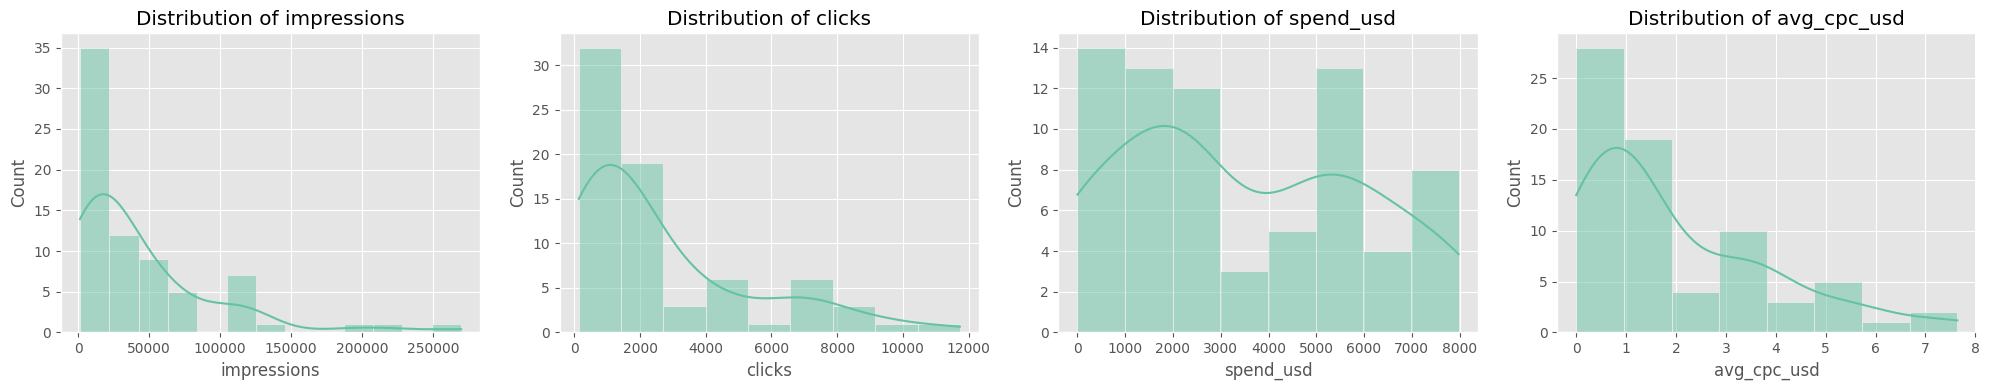

In [17]:
# --- Distribution of numeric columns in Ad Spend (Histograms) ---
num_cols = ad_spend.select_dtypes(include=np.number).columns

if len(num_cols) > 0:
    fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))
    if len(num_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, num_cols):
        sns.histplot(ad_spend[col], kde=True, ax=ax)
        ax.set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found in ad_spend")

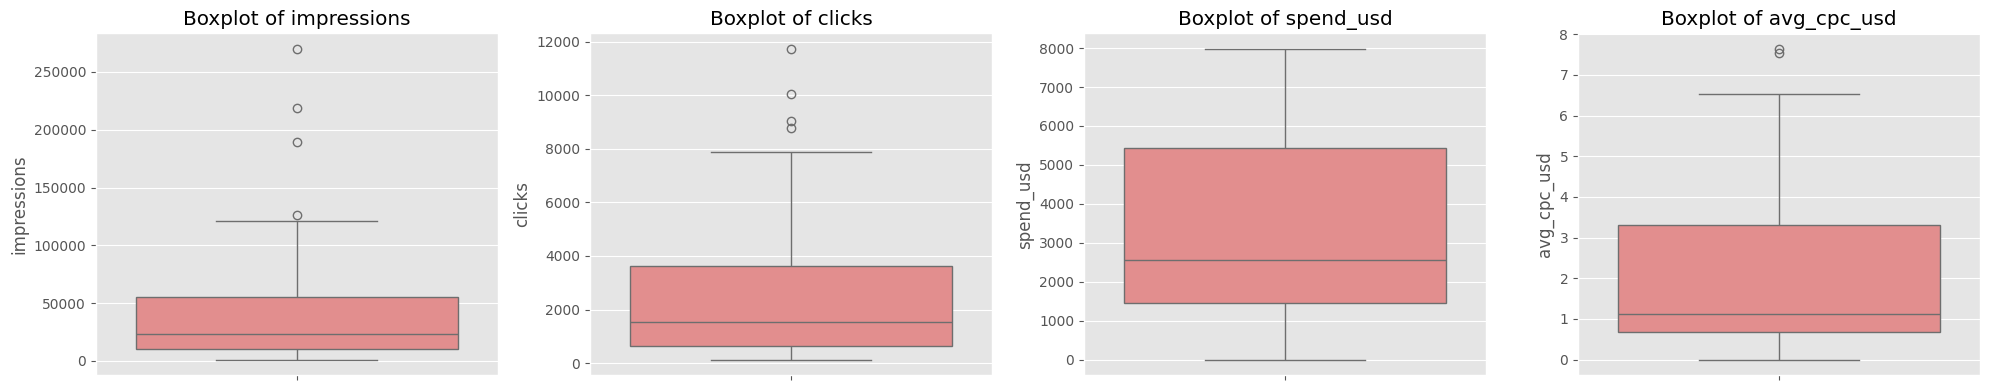

In [18]:
# --- Boxplots to spot outliers ---
if len(num_cols) > 0:
    fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))
    if len(num_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, num_cols):
        sns.boxplot(y=ad_spend[col], ax=ax, color='lightcoral')
        ax.set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

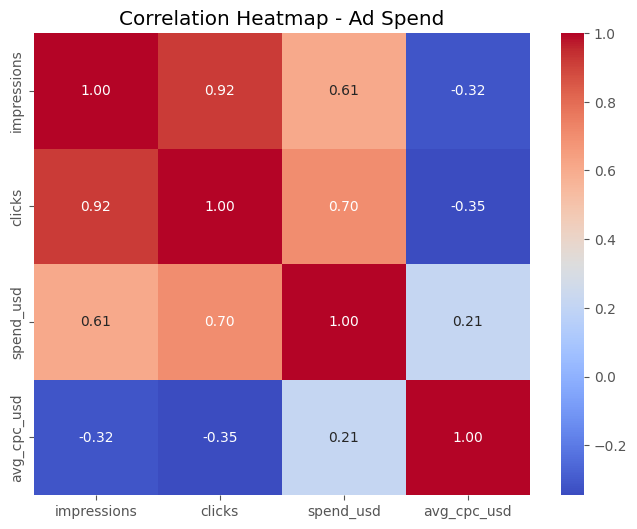

In [19]:
# --- Correlation heatmap (Ad Spend) ---
num_df = ad_spend.select_dtypes(include=np.number)

if num_df.shape[1] > 1:
    plt.figure(figsize=(8,6))
    sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap - Ad Spend')
    plt.show()
else:
    print("Not enough numeric columns for a correlation heatmap")

In [20]:
# --- Trend over time (Line chart) ---
date_col = [c for c in ad_spend.columns if 'date' in c]
spend_col = [c for c in ad_spend.columns if 'spend' in c]

if date_col and spend_col:
    daily = ad_spend.groupby(date_col[0])[spend_col[0]].sum().reset_index()
    plt.figure(figsize=(10,4))
    plt.plot(daily[date_col[0]], daily[spend_col[0]], marker='o', color='teal')
    plt.title('Ad Spend Over Time')
    plt.xlabel('Date')
    plt.ylabel(spend_col[0])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No date/spend column found for trend analysis")

No date/spend column found for trend analysis


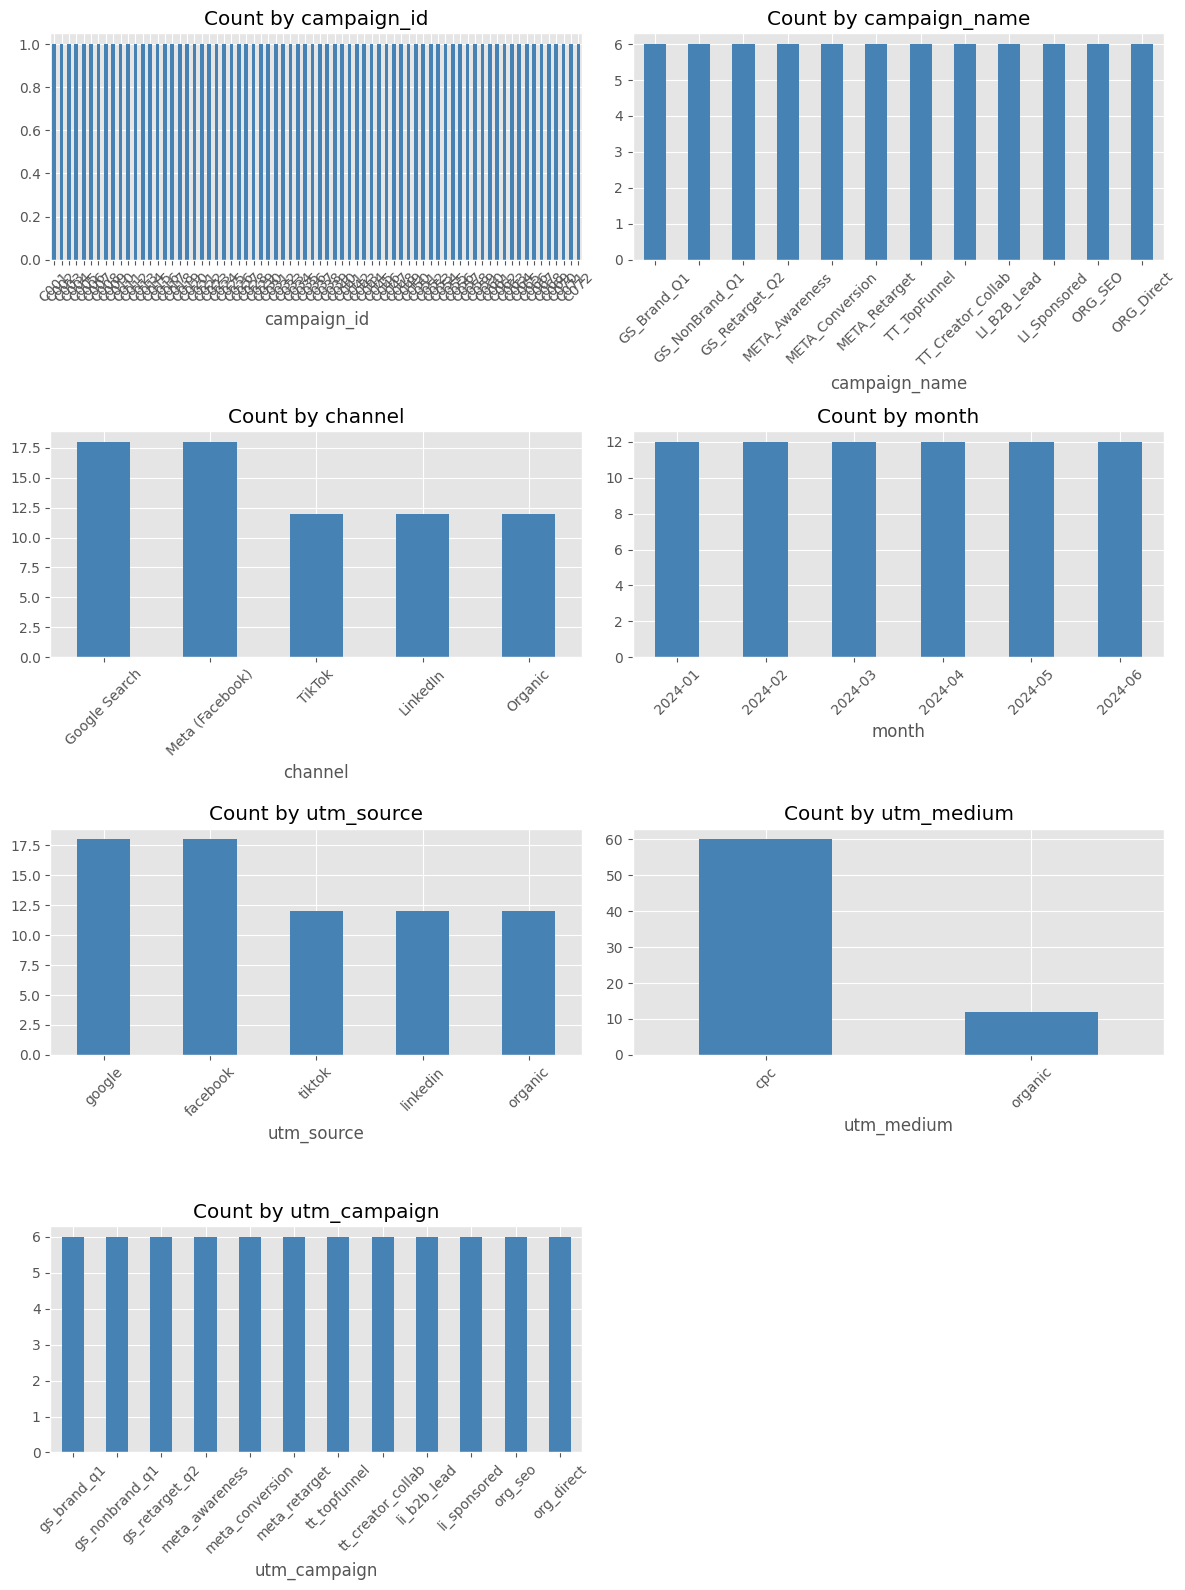

In [21]:
# --- Categorical breakdown (Bar charts) ---
cat_cols = ad_spend.select_dtypes(include='object').columns

if len(cat_cols) > 0:
    n = len(cat_cols)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, col in zip(axes, cat_cols):
        ad_spend[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'Count by {col}')
        ax.tick_params(axis='x', rotation=45)

    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found")

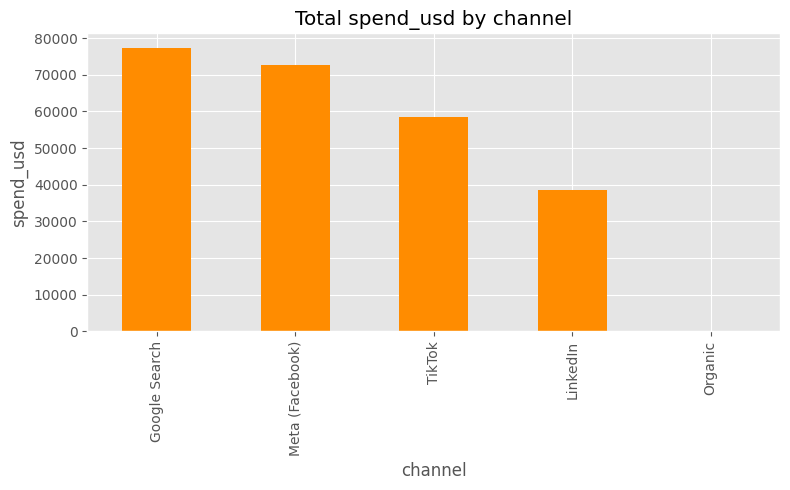

In [22]:
# --- Total spend by channel (Bar chart) ---
spend_col = [c for c in ad_spend.columns if 'spend' in c][0]
channel_col = [c for c in ad_spend.columns if 'channel' in c or 'platform' in c][0]

channel_spend = ad_spend.groupby(channel_col)[spend_col].sum().sort_values(ascending=False)

channel_spend.plot(kind='bar',
                    figsize=(8,5),
                    color='darkorange',
                    title=f'Total {spend_col} by {channel_col}')
plt.ylabel(spend_col)
plt.tight_layout()
plt.show()

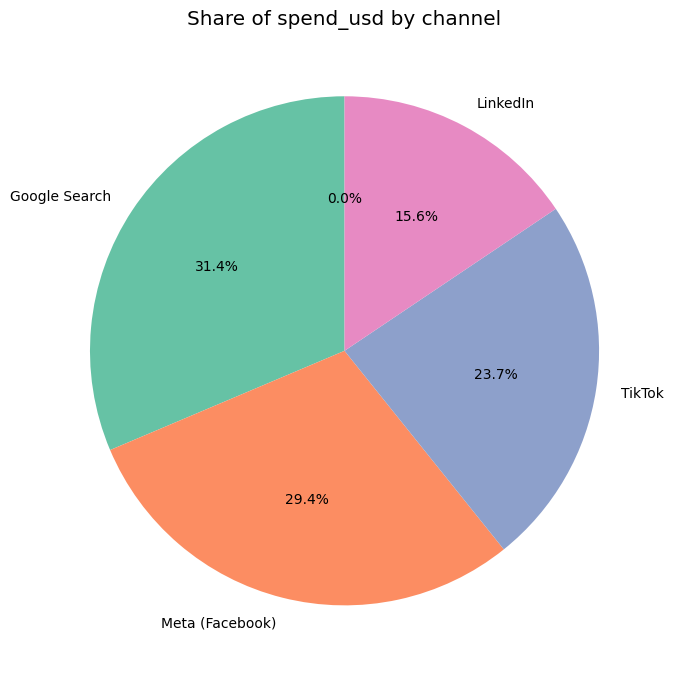

In [23]:
# --- Share of spend by channel (Pie chart) ---
plt.figure(figsize=(7,7))
channel_spend.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title(f'Share of {spend_col} by {channel_col}')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 4.3 Web Analytics Overview

In [24]:
print(web.columns.tolist())

['session_id', 'user_id', 'timestamp', 'channel', 'campaign_name', 'utm_source', 'utm_medium', 'landing_page', 'session_duration_sec', 'pages_viewed']


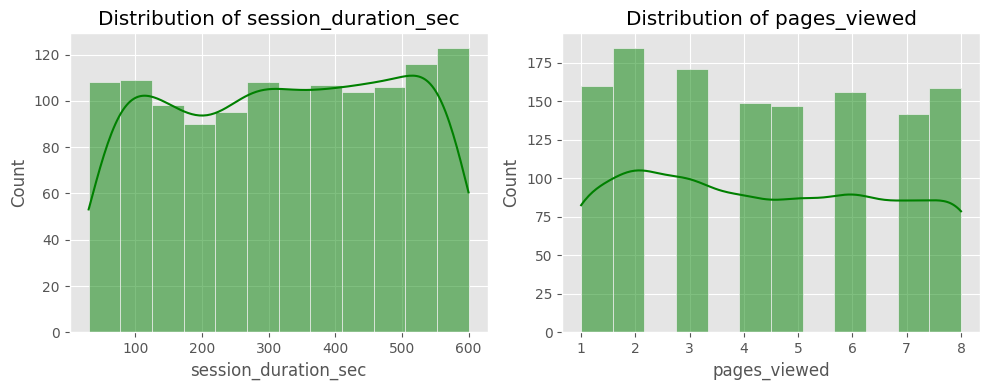

In [25]:
# --- Distribution of numeric Web Analytics columns ---
web_num_cols = web.select_dtypes(include=np.number).columns

if len(web_num_cols) > 0:
    fig, axes = plt.subplots(1, len(web_num_cols), figsize=(5*len(web_num_cols), 4))
    if len(web_num_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, web_num_cols):
        sns.histplot(web[col], kde=True, ax=ax, color='green')
        ax.set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found in web")

In [26]:
# --- Web metrics over time (Line chart) ---
web_date_col = [c for c in web.columns if 'date' in c]

if web_date_col and len(web_num_cols) > 0:
    daily_web = web.groupby(web_date_col[0])[web_num_cols].sum().reset_index()
    plt.figure(figsize=(10,5))
    for col in web_num_cols[:3]:
        plt.plot(daily_web[web_date_col[0]], daily_web[col], marker='o', label=col)
    plt.title('Web Analytics Metrics Over Time')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No date column or numeric columns found for trend analysis")

No date column or numeric columns found for trend analysis


### 4.4 CRM Conversions Overview

In [27]:
print(crm.columns.tolist())

['conversion_id', 'user_id', 'conversion_date', 'order_value_usd', 'product_category', 'payment_method', 'country', 'is_new_customer']


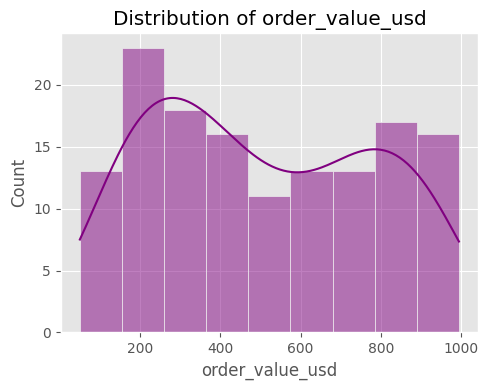

In [28]:
# --- Distribution of numeric CRM columns ---
crm_num_cols = crm.select_dtypes(include=np.number).columns

if len(crm_num_cols) > 0:
    fig, axes = plt.subplots(1, len(crm_num_cols), figsize=(5*len(crm_num_cols), 4))
    if len(crm_num_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, crm_num_cols):
        sns.histplot(crm[col], kde=True, ax=ax, color='purple')
        ax.set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found in crm")

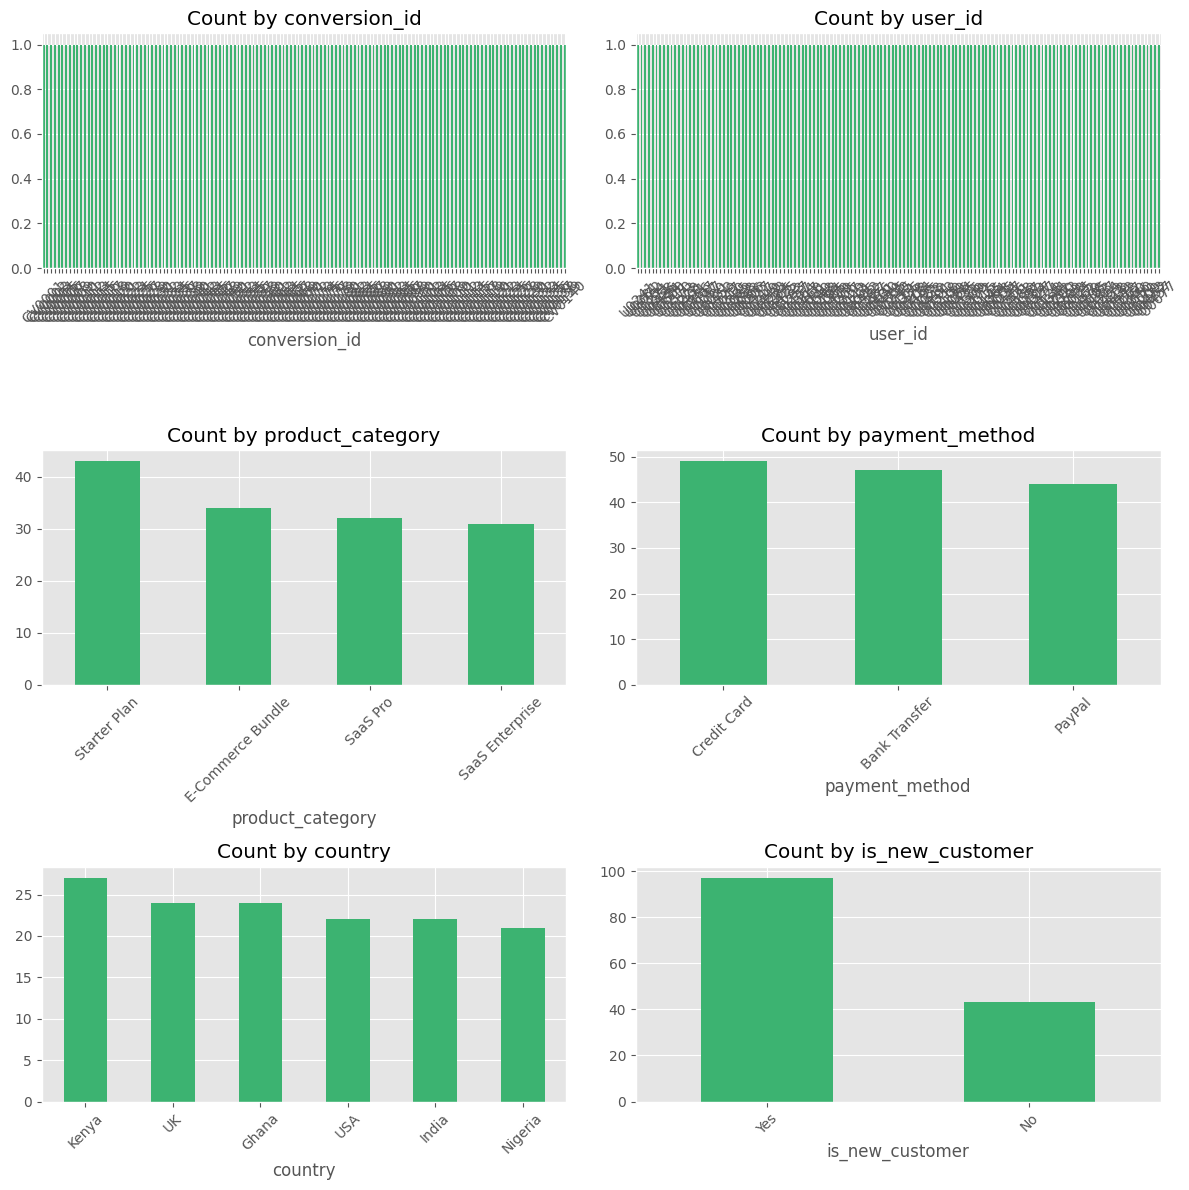

In [29]:
# --- CRM categorical breakdown (e.g., conversion type/stage) ---
crm_cat_cols = crm.select_dtypes(include='object').columns

if len(crm_cat_cols) > 0:
    n = len(crm_cat_cols)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, col in zip(axes, crm_cat_cols):
        crm[col].value_counts().plot(kind='bar', ax=ax, color='mediumseagreen')
        ax.set_title(f'Count by {col}')
        ax.tick_params(axis='x', rotation=45)

    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found in crm")